In [1]:
import os
import sys
import requests
import datetime as dt
import numpy as np
from dotenv import load_dotenv
from pathlib import Path
import requests
import pandas as pd
import talib as ta
import plotly.graph_objs as go
import kaleido 

import ipywidgets as widgets
from ipywidgets import Dropdown, Text, Button, Output
from IPython.display import display

from Modules.utility import Utility
from Modules.show_plot import ShowPlot
from Modules.reques_api import RequestApi
from Modules.get_market_data import GetMarketData
from Modules.stock_prices_and_market_data import ClassStockPricesMarketData
from Modules.financial import Financial
from Modules.pdf_url_to_markdown import PDFUrlToMarkdown
from Modules.webpage_to_markdown import WebpageToMarkdown
from Modules.compute_fibonacci_extension import ComputeFibonacciExtension

In [2]:
API_BASE_URL = os.getenv("API_BASE_URL", "http://localhost:8000")
request_api = RequestApi(API_BASE_URL)
get_market_data = GetMarketData(Path('/workspace/data'))
utility = Utility()
stock_prices_market_data = ClassStockPricesMarketData()
financial = Financial()
# URLからPDFをダウンロードしてMarkdownに変換するクラスのインスタンスを作成
pdf_to_md = PDFUrlToMarkdown()
# WEBページをMarkdownに変換する関数
webpage_to_markdown = WebpageToMarkdown()
# 
fibonacci_extension = ComputeFibonacciExtension()

In [3]:
nikkei = '^N225'
market = 'T'
start = '1999-01-01'
end = dt.datetime.now().strftime('%Y-%m-%d')
response = request_api.update_commodity_timeseries_data(
    code=nikkei,
    market=None,
    start=start,
    end=end
)
response

{'result': True}

In [4]:
nikkei_df = request_api.get_commodity_time_series_data(
    code=nikkei,
    market=None,
    start=start,
    end=end
)
nikkei_df.head()

取得件数: 6751


,id,commodity_id,commodity_code,commodity_market,date,open,high,low,close,adj_close,...,rci9,rci26,cross,gc,dc,macd_gc,macd_dc,rci_gc,rci_dc,rising_condition
0,45101,3,^N225,None,1998-11-17,14413.000000,14480.500000,14276.809570,14475.879883,None,...,NaN,NaN,False,NaN,NaN,NaN,NaN,NaN,NaN,False
1,45102,3,^N225,None,1998-11-18,14599.230469,14701.450195,14383.360352,14396.089844,None,...,NaN,NaN,False,NaN,NaN,NaN,NaN,NaN,NaN,False
2,45103,3,^N225,None,1998-11-19,14354.459961,14642.959961,14354.410156,14557.099609,None,...,NaN,NaN,False,NaN,NaN,NaN,NaN,NaN,NaN,False
3,45104,3,^N225,None,1998-11-20,14779.940430,14779.940430,14461.200195,14461.200195,None,...,NaN,NaN,False,NaN,NaN,NaN,NaN,NaN,NaN,False
4,45105,3,^N225,None,1998-11-24,15164.639648,15164.639648,14904.200195,14904.200195,None,...,NaN,NaN,False,NaN,NaN,NaN,NaN,NaN,NaN,False


In [5]:
code = '5713'
market = 'T'
start = '1999-01-01'
end = dt.datetime.now().strftime('%Y-%m-%d')

response = request_api.update_stock_timeseries_data(
    code=code,
    market=market,
    start=start,
    end=end
)
response

{'result': True}

In [6]:
sumitomo_timeseries_df = request_api.get_stock_time_series_data(
    code=code,
    market=market,
    start=start,
    end=end
)
sumitomo_timeseries_df.head()

取得件数: 6598


,id,stock_code,stock_market,date,open,high,low,close,volume,ma5,...,upper1,lower1,cross,gc,dc,macd_gc,macd_dc,rci_gc,rci_dc,rising_condition
0,1211292,5713,T,2000-01-04,257.819763,260.081340,254.427398,260.081340,263500,NaN,...,NaN,NaN,False,NaN,NaN,NaN,NaN,NaN,NaN,False
1,1211293,5713,T,2000-01-05,265.735321,265.735321,252.165858,252.165858,539000,NaN,...,NaN,NaN,False,NaN,NaN,NaN,NaN,NaN,NaN,False
2,1211294,5713,T,2000-01-06,265.735321,267.996898,257.819801,267.996898,501000,NaN,...,NaN,NaN,False,NaN,NaN,NaN,NaN,NaN,NaN,False
3,1211295,5713,T,2000-01-07,261.212219,267.996952,258.950642,265.735375,976000,NaN,...,NaN,NaN,False,NaN,NaN,NaN,NaN,NaN,NaN,False
4,1211296,5713,T,2000-01-10,261.212219,261.212219,261.212219,261.212219,0,261.438338,...,NaN,NaN,False,NaN,NaN,NaN,NaN,NaN,NaN,False


In [7]:
def stock_prices_and_gold_prices(
        code: str,
        name: str,
        start: str,
        end: str,
        df_sp: pd.DataFrame | None = None,
        df_gold: pd.DataFrame | None = None,
        df_silver: pd.DataFrame | None = None
    ):
    # /api/v1/time_series_data/stock/
    response = request_api.get_stock_time_series_data(
        code=code,
        market=None,
        start=start,
        end=end
    )
    df_stock = pd.DataFrame(response)

    # NIKKEI225を統合
    if df_sp is not None:
        df_sp_tmp = df_sp.copy() if df_sp is not None else pd.DataFrame()
        if "date" not in df_sp_tmp.columns:
            df_sp_tmp = df_sp_tmp.reset_index()

        df_sp_tmp["date"] = pd.to_datetime(df_sp_tmp["date"])
        df_sp_tmp = df_sp_tmp.set_index("date")
        df_sp_tmp = df_sp_tmp.loc[start:end]

    # 金価格を統合
    if df_gold is not None:
        df_gold_tmp = df_gold.copy() if df_gold is not None else pd.DataFrame()
        if "date" not in df_gold_tmp.columns:
            df_gold_tmp = df_gold_tmp.reset_index()
        df_gold_tmp["date"] = pd.to_datetime(df_gold_tmp["date"])
        df_gold_tmp = df_gold_tmp.set_index("date")
        df_gold_tmp = df_gold_tmp.loc[start:end]

    # 銀価格を統合
    if df_silver is not None:
        df_silver_tmp = df_silver.copy() if df_silver is not None else pd.DataFrame()
        if "date" not in df_silver_tmp.columns:
            df_silver_tmp = df_silver_tmp.reset_index()
        df_silver_tmp["date"] = pd.to_datetime(df_silver_tmp["date"])
        df_silver_tmp = df_silver_tmp.set_index("date")
        df_silver_tmp = df_silver_tmp.loc[start:end]

    # 金価格
    df = df_stock.copy()
    df["date"] = pd.to_datetime(df["date"])
    df = df.set_index("date")
    df = df.loc[start:end]


    # インデックスを揃えて結合
    if df_sp is not None:
        df["MA5_NIKKEI225"] = df_sp_tmp["ma5"].reindex(df.index)
        df["MA25_NIKKEI225"] = df_sp_tmp["ma25"].reindex(df.index)
    if df_gold is not None:
        df["MA5_GOLD"] = df_gold_tmp["ma5"].reindex(df.index)
        df["MA25_GOLD"] = df_gold_tmp["ma25"].reindex(df.index)
    if df_silver is not None:
        df["MA5_SILVER"] = df_silver_tmp["ma5"].reindex(df.index)
        df["MA25_SILVER"] = df_silver_tmp["ma25"].reindex(df.index)

    show_plot = ShowPlot()
    fig = show_plot.create_basic_chart(
        df=df.reset_index(),
        code=code,
        name=name,
        start=start,
        end=end
    )
    # ★ 2つのY軸を定義（左：HYMC、右：SP500 & GOLD）
    fig.update_layout(
        yaxis=dict(
            title=f"{name} Price",
            side="left"
        ),
        yaxis2=dict(
            title="SP500 / GOLD",
            overlaying="y",
            side="right"
        )
    )

    # --- NIKKEI225（右軸） ---
    if df_sp is not None:
        fig.add_trace(
            go.Scatter(
                x=df.index,
                y=df["MA5_NIKKEI225"],
                name="NIKKEI225_MA5",
                line={"color": "blue", "width": 1.2},
                yaxis="y2"   # ★ 右軸
            )
        )
        fig.add_trace(
            go.Scatter(
                x=df.index,
                y=df["MA25_NIKKEI225"],
                name="NIKKEI225_MA25",
                line={"color": "gray", "width": 1.2},
                yaxis="y2"   # ★ 右軸
            )
        )

    # --- GOLD（右軸） ---
    if df_gold is not None:
        fig.add_trace(
            go.Scatter(
                x=df.index,
                y=df["MA5_GOLD"],
                name="GOLD_MA5",
                line={"color": "orange", "width": 1.2},
                yaxis="y2"   # ★ 右軸
            )
        )
        fig.add_trace(
            go.Scatter(
                x=df.index,
                y=df["MA25_GOLD"],
                name="GOLD_MA25",
                line={"color": "yellow", "width": 1.2},
                yaxis="y2"   # ★ 右軸
            )
        )

    # --- SILVER（左軸） ---
    if df_silver is not None:
        fig.add_trace(
            go.Scatter(
                x=df.index,
                y=df["MA5_SILVER"],
                name="SILVER_MA5",
                line={"color": "gray", "width": 1.2},
                yaxis="y"   # ★ 左軸
            )
        )
        fig.add_trace(
            go.Scatter(
                x=df.index,
                y=df["MA25_SILVER"],
                name="SILVER_MA25",
                line={"color": "black", "width": 1.2},
                yaxis="y"   # ★ 左軸
            )
        )

    return fig

In [8]:
name = "Sumitomo Metal Mining Co., Ltd. (5713.T)"
start = dt.datetime(2026, 1, 1).strftime("%Y-%m-%d")
end = dt.datetime.now().strftime('%Y-%m-%d')
# グラフ領域の作成
fig = stock_prices_and_gold_prices(
    code=code,
    name=name,
    start=start,
    end=end,
    df_sp=nikkei_df,
    df_gold=None,
    df_silver=None
)
fig.show()

取得件数: 309


In [9]:
from pathlib import Path

# 例: すでに作成済みの fig を保存
output_dir = Path("/workspace/data/figures")
output_dir.mkdir(parents=True, exist_ok=True)

output_path = output_dir / f"{code}_{start}_{end}.png"
fig.write_image(str(output_path), width=1600, height=900, scale=2)

print("saved:", output_path)

saved: /workspace/data/figures/5713_2026-01-01_2026-06-15.png


In [10]:
output_dir = Path("/workspace/data/")
output_dir.mkdir(parents=True, exist_ok=True)
output_path = output_dir / f"SUMITOMO_data_{dt.datetime.now().strftime("%Y-%m-%d")}.csv"

df = sumitomo_timeseries_df.copy()
end = dt.datetime.now().strftime('%Y-%m-%d')
df = df.reset_index()
df["date"] = pd.to_datetime(df["date"])
df = df.set_index("date")
df = df.loc['2026-01-01':end]
df.to_csv(output_path)
df.head()

,index,id,stock_code,stock_market,open,high,low,close,volume,ma5,...,upper1,lower1,cross,gc,dc,macd_gc,macd_dc,rci_gc,rci_dc,rising_condition
date,,,,,,,,,,,,,,,,,,,,,
2026-01-05,6491,1217783,5713,T,6523.841309,6558.239387,6439.320315,6506.150868,3531600,6386.445581,...,6103.527878,5126.049404,True,NaN,NaN,NaN,NaN,NaN,NaN,False
2026-01-06,6492,1217784,5713,T,6937.601074,7039.812508,6827.527222,6830.475629,5133900,6477.256498,...,6213.880847,5167.047961,True,NaN,NaN,NaN,NaN,NaN,NaN,False
2026-01-07,6493,1217785,5713,T,7050.623535,7221.631131,7000.500619,7074.210790,5342200,6636.667062,...,6342.049199,5210.123084,True,NaN,NaN,NaN,NaN,NaN,NaN,False
2026-01-08,6494,1217786,5713,T,6917.945312,7161.680280,6897.306464,7050.623622,3157400,6745.365035,...,6454.337454,5257.520560,True,NaN,NaN,NaN,NaN,NaN,NaN,False
2026-01-09,6495,1217787,5713,T,7047.675293,7105.660629,6925.807808,7065.365734,2998500,6905.365329,...,6555.811634,5319.506080,True,NaN,NaN,NaN,NaN,NaN,NaN,False


{'fib_levels_down': {'1.000': np.float64(6439.320315442339),
  '1.272': np.float64(4635.4300290060655),
  '1.382': np.float64(3905.9155749325723),
  '1.618': np.float64(2340.7754734658056)},
 'fib_levels_up': {'1.272': np.float64(14875.160184364913),
  '1.382': np.float64(15604.674638438406),
  '1.618': np.float64(17169.814739905174),
  '2.000': np.float64(19703.21948041494)},
 'swing_high': np.float64(13071.26989792864),
 'swing_low': np.float64(6439.320315442339),
 'df_with_fib':           date  index       id stock_code stock_market         open  \
 0   2026-01-05   6491  1217783       5713            T  6523.841309   
 1   2026-01-06   6492  1217784       5713            T  6937.601074   
 2   2026-01-07   6493  1217785       5713            T  7050.623535   
 3   2026-01-08   6494  1217786       5713            T  6917.945312   
 4   2026-01-09   6495  1217787       5713            T  7047.675293   
 ..         ...    ...      ...        ...          ...          ...   
 102 2026-

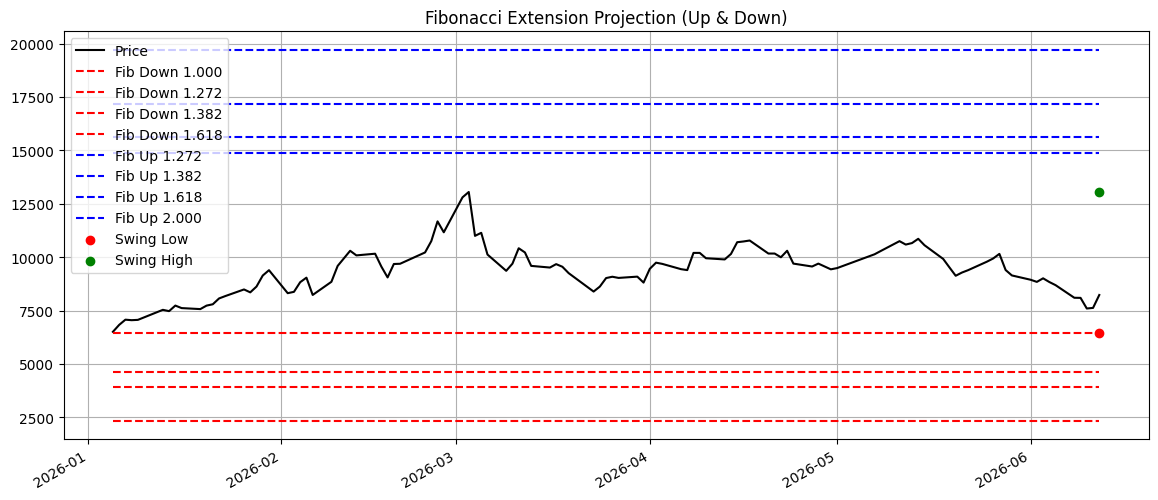

In [11]:
fib_result = fibonacci_extension.compute_fibonacci_extension(df.copy().reset_index())
fib_result

In [12]:
output_dir = Path("/workspace/data/figures/")
output_dir.mkdir(parents=True, exist_ok=True)
output_path = output_dir / f"SUMITOMO_fibonacci_extension_{dt.datetime.now().strftime('%Y-%m-%d')}.png"
fib_result["plot_obj"].savefig(output_path, dpi=300, bbox_inches="tight")

In [ ]:
md_file_path =pdf_to_md.pdf_url_to_markdown(
    pdf_url="",
    directory_path="/workspace/data",
)
md_file_path